In [1]:
import numpy as np
from surmof_cavity import ag_surmof_cavity_det_smat as det_smat
from surmof_cavity import ag_surmof_core_shell as core_shell
import matplotlib.pyplot as plt
import matplotlib as mpl
from functools import partial
from diffaaable.selective import selective_refinement_aaa
import pickle
from tqdm import tqdm

In [2]:
import scipy.io
scipy.io.matlab.loadmat("Materials_SILVER_SURMOF.mat")

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Mon Jul 15 17:52:14 2024',
 '__version__': '1.0',
 '__globals__': [],
 'epsinf_SURMOF': array([[1.64166343+7.28225082e-15j]]),
 'epsinf_Silver': array([[4.60853575+1.6674063e-13j]]),
 'poles_SURMOF': array([[ 8.64988292-0.05305478j, -8.64988292-0.05305478j,
         -9.17312074-0.04800844j,  9.17312074-0.04800844j,
          9.37767693-0.04977859j, -9.37767693-0.04977859j]]),
 'poles_Silver': array([[ 0.00000000e+00+0.j        , -5.41264517e-16-0.21903558j]]),
 'residues_SURMOF': array([[-0.8089228 +0.01159594j,  0.8089228 +0.01159594j,
          0.09386756-0.02744344j, -0.09386756-0.02744344j,
         -0.06534631+0.01437131j,  0.06534631+0.01437131j]]),
 'residues_Silver': array([[-4.80133244e-11+9055.13508475j,  4.79859659e-11-9054.96089819j]])}

In [3]:
0.5*(9055.13508475+9054.96089819)

9055.04799147

In [4]:
%config InlineBackend.figure_format='retina'

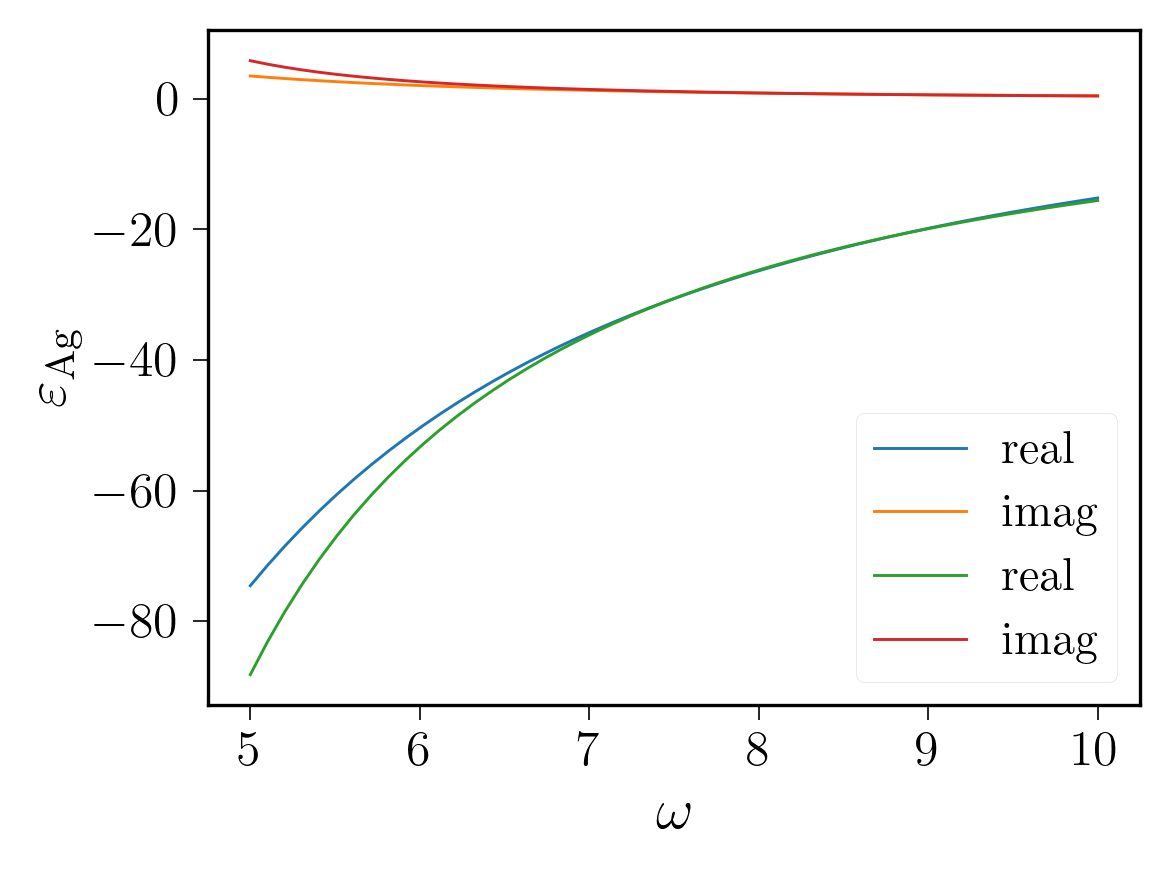

In [5]:
wfreq = np.linspace(5, 10)

eps_Ag = 4.60853575 + 9055.04799147j * (1/(wfreq) - 1/(wfreq+0.21903558j))

Agw0 = 2*np.pi*134.39519365 / 300
Aggamma = 2*np.pi*10.61865288 / 300
Agwp = 2*np.pi*1867.27147966 / 300

eps_Ag_prev = 1 + Agwp**2 / (Agw0**2 - wfreq**2 - 1j*Aggamma*wfreq)

plt.plot(wfreq, eps_Ag.real, label="real")
plt.plot(wfreq, eps_Ag.imag, label="imag")

plt.plot(wfreq, eps_Ag_prev.real, label="real")
plt.plot(wfreq, eps_Ag_prev.imag, label="imag")

plt.xlabel("$\omega$")
plt.ylabel(r"$\varepsilon_\mathrm{Ag}$")
plt.legend()

In [6]:
np.array([448.79110491874115, 438.2930673770547, 412.93727009075883])/300*2*np.pi

array([9.39945892, 9.17958854, 8.64853796])

In [7]:
toTHz = 300/(2*np.pi)

In [8]:
all_poles = []
all_residues = []

In [9]:
np.array([380, 490, -3.7, -2.5])/300*(2*np.pi)

array([ 7.95870139, 10.262536  , -0.07749262, -0.05235988])

In [10]:
ts = 0.025*(np.arange(55)+1)
npoles = 1
for thickness in tqdm(ts[30:]):
    #f = partial(det_smat, thickness=thickness, npoles=npoles)
    f = partial(core_shell, d_core=thickness, npoles=npoles, l=1)
    poles, residues, evals = selective_refinement_aaa(f, domain=[7.5-2j, 10.5-0.04j], 
                    N=400, use_adaptive=False, tol_pol=1e-6, Dmax=11) #[5.008-1.005j, 20+0.05j]
    all_poles.append(poles)
    all_residues.append(residues)

    with open("core_shell_1pole_dipole_deep_complex_plane.pkl", "wb") as file:
        pickle.dump({"poles":all_poles, "residues": all_residues, "thickness":ts[:len(all_poles)]}, file)
    

  0%|          | 0/25 [03:02<?, ?it/s]


KeyboardInterrupt: 

(-3.7, -2.5)

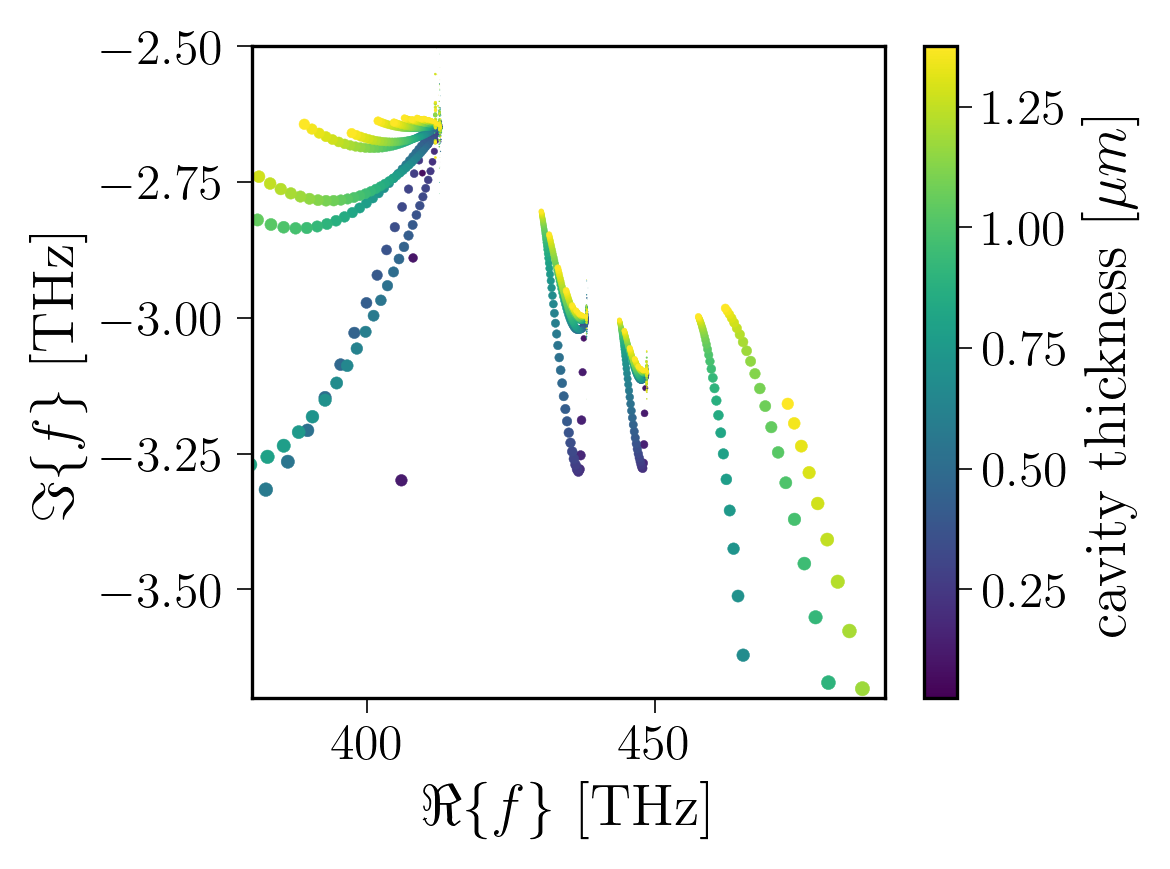

In [ ]:
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=min(ts), vmax=max(ts))
colors = cmap(norm(ts))
for color, poles, residues in zip(colors, all_poles, all_residues):
    filtered_poles = poles[poles.imag<-0.01]
    plt.scatter(filtered_poles.real*toTHz, filtered_poles.imag*toTHz, color=color, s=np.sqrt(np.abs(residues))*100)

plt.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm), ax=plt.gca(), label="cavity thickness [$\mu m$]")

plt.xlabel("$\Re\{f\}$ [THz]")
plt.ylabel("$\Im\{f\}$ [THz]")
plt.savefig("pole_movement.png", dpi=600)
plt.xlim(380, 490)
plt.ylim(-3.7, -2.5)

# plt.xlim(445, 449)
# plt.ylim(-3.4, -3)

# plt.xlim(435, 439)
# plt.ylim(-3.2, -2.95)